# PuLP 混合整数线性规划示例

下面给出一个简单的混合整数线性规划（MILP）问题，其中：

- `x` 为整数变量
- `y` 为连续变量
- `z` 为 0-1 变量

$$
\max \; 5x + 3y - 2z
$$

约束条件为：

$$
\begin{aligned}
2x + y &\leq 10 \\
x + y &\leq 6 \\
x &\leq 4z \\
x &\in \mathbb{Z}_{\geq 0} \\
y &\geq 0 \\
z &\in \{0,1\}
\end{aligned}
$$

这里 `x <= 4z` 表示：只有当 `z = 1` 时，整数变量 `x` 才允许取正值。


In [1]:
import pulp

# 1. 创建一个最大化问题
model = pulp.LpProblem('Simple_MILP', pulp.LpMaximize)

# 2. 定义变量
x = pulp.LpVariable('x', lowBound=0, cat='Integer')
y = pulp.LpVariable('y', lowBound=0, cat='Continuous')
z = pulp.LpVariable('z', cat='Binary')

# 3. 目标函数
model += 5 * x + 3 * y - 2 * z, 'Objective'

# 4. 约束条件
model += 2 * x + y <= 10, 'Constraint_1'
model += x + y <= 6, 'Constraint_2'
model += x <= 4 * z, 'Constraint_3'

# 5. 求解
model.solve()

# 6. 输出结果
print('求解状态:', pulp.LpStatus[model.status])
print('最优目标值 =', pulp.value(model.objective))
print('x =', x.varValue)
print('y =', y.varValue)
print('z =', z.varValue)


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/zhangyoulun/codes/zhyoulun/blog/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/94/rtd3cpfd581g16md5_477nrr0000gp/T/c0062416f9a74a989085ffeef1e66a27-pulp.mps -max -timeMode elapsed -solve -printingOptions all -solution /var/folders/94/rtd3cpfd581g16md5_477nrr0000gp/T/c0062416f9a74a989085ffeef1e66a27-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 8 COLUMNS
At line 22 RHS
At line 26 BOUNDS
At line 29 ENDATA
Problem MODEL has 3 rows, 3 columns and 6 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 24 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 1 strengthened rows, 0 substitutions
Cgl0004I processed model has 3 rows, 3 columns (3 integer (1 of which binary)) and 7 elements
Cutoff increment increased from 1e-05 to 0.9999
Cbc0038I Initial sta

## 使用 Matplotlib 可视化 MILP

下图展示约束边界、连续松弛可行域、整数变量 `x` 的可行取值位置，以及最优解点。


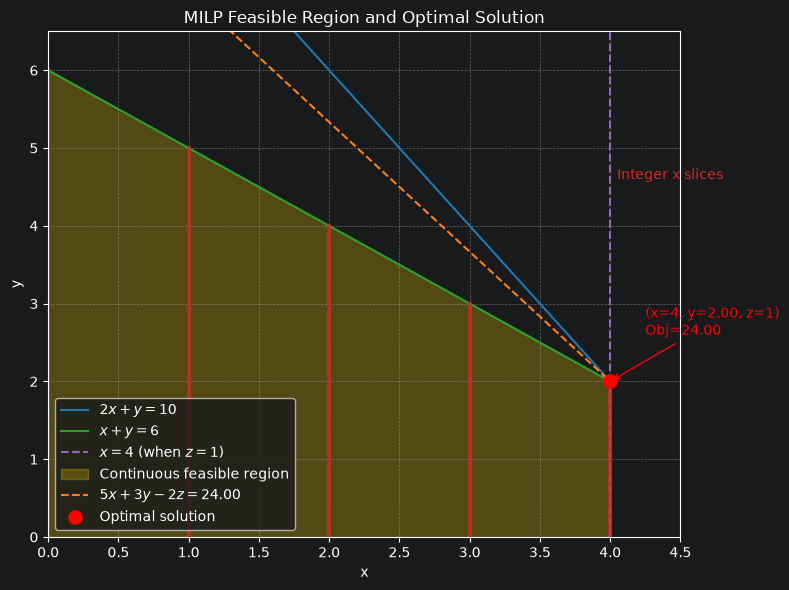

In [2]:
import numpy as np
import matplotlib.pyplot as plt

optimal_x = x.varValue
optimal_y = y.varValue
optimal_z = z.varValue
objective_value = pulp.value(model.objective)

x_values = np.linspace(0, 4, 400)
y1 = 10 - 2 * x_values
y2 = 6 - x_values
y_top = np.minimum(y1, y2)
y_top = np.maximum(y_top, 0)

plt.figure(figsize=(8, 6))
plt.plot(x_values, y1, label=r'$2x + y = 10$', color='tab:blue')
plt.plot(x_values, y2, label=r'$x + y = 6$', color='tab:green')
plt.axvline(4, color='tab:purple', linestyle='--', label=r'$x = 4$（当 $z=1$ 时）')

plt.fill_between(
    x_values,
    0,
    y_top,
    where=y_top >= 0,
    color='gold',
    alpha=0.25,
    label='连续可行域'
)

for xi in range(5):
    yi_max = min(10 - 2 * xi, 6 - xi)
    if yi_max >= 0:
        plt.plot([xi, xi], [0, yi_max], color='tab:red', linewidth=3, alpha=0.7)

plt.text(4.05, 4.6, '整数可行切片', color='tab:red')

objective_y = (objective_value + 2 * optimal_z - 5 * x_values) / 3
plt.plot(
    x_values,
    objective_y,
    color='tab:orange',
    linestyle='--',
    label=rf'$5x + 3y - 2z = {objective_value:.2f}$'
)

plt.scatter(optimal_x, optimal_y, color='red', s=90, zorder=5, label='唯一最优解')
plt.annotate(
    f'唯一最优解\n(x={optimal_x:.0f}, y={optimal_y:.2f}, z={optimal_z:.0f})\n目标值={objective_value:.2f}',
    xy=(optimal_x, optimal_y),
    xytext=(optimal_x + 0.25, optimal_y + 0.6),
    arrowprops={'arrowstyle': '->', 'color': 'red'},
    color='red'
)

plt.xlim(0, 4.5)
plt.ylim(0, 6.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('MILP 可行域与唯一最优解')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
